In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


In [2]:
df = pd.read_csv("customer_data.csv")

print("HEAD")
print(df.head())

print("\nINFO")
print(df.info())

print("\nDESCRIBE")
print(df.describe())

HEAD
   Customer ID  Gender  Age           City Membership Type  Total Spend  \
0          101  Female   29       New York            Gold      1120.20   
1          102    Male   34    Los Angeles          Silver       780.50   
2          103  Female   43        Chicago          Bronze       510.75   
3          104    Male   30  San Francisco            Gold      1480.30   
4          105    Male   27          Miami          Silver       720.40   

   Items Purchased  Average Rating  Discount Applied  \
0               14             4.6              True   
1               11             4.1             False   
2                9             3.4              True   
3               19             4.7             False   
4               13             4.0              True   

   Days Since Last Purchase Satisfaction Level  
0                        25          Satisfied  
1                        18            Neutral  
2                        42        Unsatisfied  
3          

In [3]:
print("\nMissing values")
print(df.isnull().sum())

df = df.dropna()

df["Gender"] = df["Gender"].astype("category")
df["City"] = df["City"].astype("category")
df["Membership Type"] = df["Membership Type"].astype("category")
df["Satisfaction Level"] = df["Satisfaction Level"].astype("category")
df["Discount Applied"] = df["Discount Applied"].astype("bool")



Missing values
Customer ID                 0
Gender                      0
Age                         0
City                        0
Membership Type             0
Total Spend                 0
Items Purchased             0
Average Rating              0
Discount Applied            0
Days Since Last Purchase    0
Satisfaction Level          2
dtype: int64


In [4]:
df["Age Group"] = pd.cut(
    df["Age"],
    bins=[18,25,35,45,60],
    labels=["18-25","25-35","35-45","45+"]
)

print("\nAge Groups")
print(df["Age Group"].value_counts())



Age Groups
Age Group
25-35    234
35-45    114
18-25      0
45+        0
Name: count, dtype: int64


In [5]:
segment = df.groupby(
    ["Membership Type","Gender","City"]
).agg({
    "Total Spend":"mean",
    "Items Purchased":"mean",
    "Average Rating":"mean"
})

print("\nSEGMENTATION")
print(segment)


SEGMENTATION
                                      Total Spend  Items Purchased  \
Membership Type Gender City                                          
Bronze          Female Chicago         499.882759         9.413793   
                       Houston         447.648214         7.589286   
Gold            Female New York       1164.250000        15.241379   
                Male   New York       1210.600000        17.000000   
                       San Francisco  1459.772414        20.000000   
Silver          Female Miami           730.400000        14.000000   
                Male   Los Angeles     805.491525        11.677966   
                       Miami           689.687719        11.596491   

                                      Average Rating  
Membership Type Gender City                           
Bronze          Female Chicago              3.456897  
                       Houston              3.191071  
Gold            Female New York             4.539655  
          

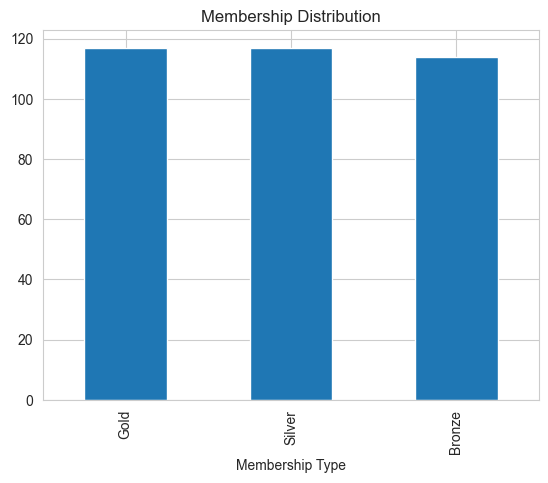

In [6]:
df["Membership Type"].value_counts().plot(
    kind="bar",
    title="Membership Distribution"
)
plt.show()

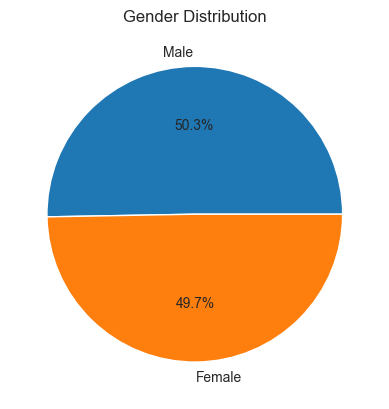

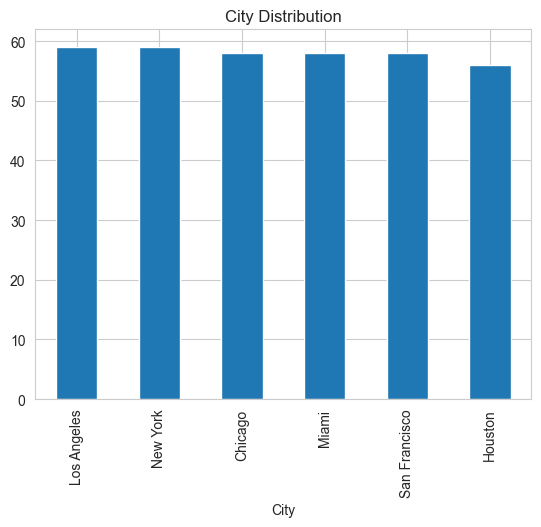

In [7]:
df["Gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    title="Gender Distribution"
)
plt.show()



df["City"].value_counts().plot(
    kind="bar",
    title="City Distribution"
)
plt.show()


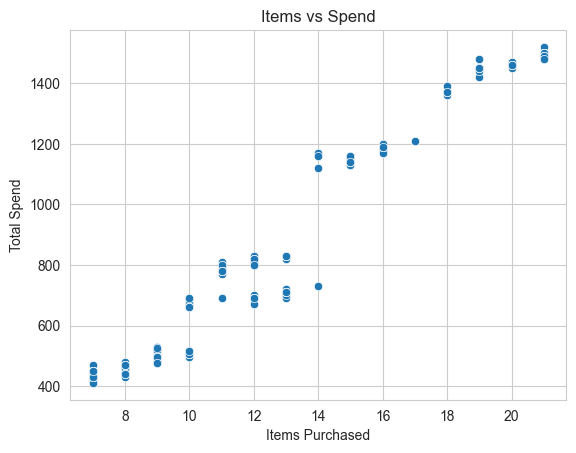


Spend by Membership
Membership Type
Bronze     474.223684
Gold      1311.144444
Silver     748.432479
Name: Total Spend, dtype: float64


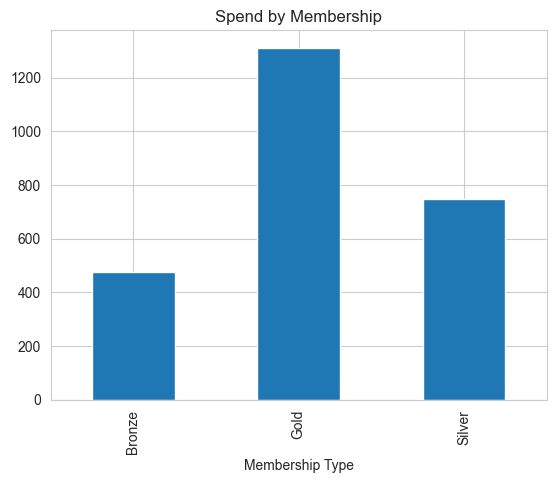

In [8]:
sns.scatterplot(
    x="Items Purchased",
    y="Total Spend",
    data=df
)

plt.title("Items vs Spend")
plt.show()


spend_membership = df.groupby(
    "Membership Type"
)["Total Spend"].mean()

print("\nSpend by Membership")
print(spend_membership)

spend_membership.plot(
    kind="bar",
    title="Spend by Membership"
)
plt.show()


Discount Effect
Discount Applied
False    909.012139
True     787.273714
Name: Total Spend, dtype: float64


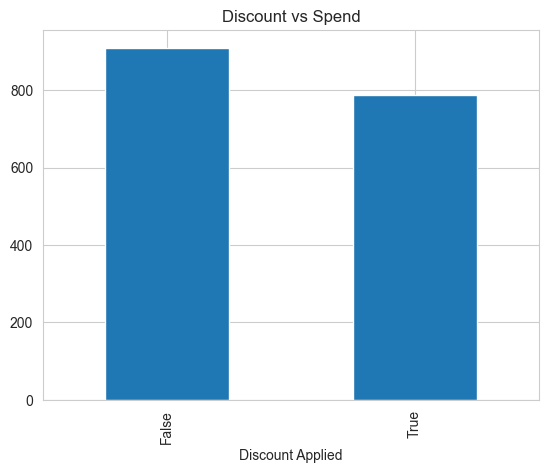

In [9]:
discount = df.groupby(
    "Discount Applied"
)["Total Spend"].mean()

print("\nDiscount Effect")
print(discount)

discount.plot(
    kind="bar",
    title="Discount vs Spend"
)
plt.show()


Satisfaction vs Spend
Satisfaction Level
Neutral         616.414019
Satisfied      1280.319200
Unsatisfied     595.136207
Name: Total Spend, dtype: float64


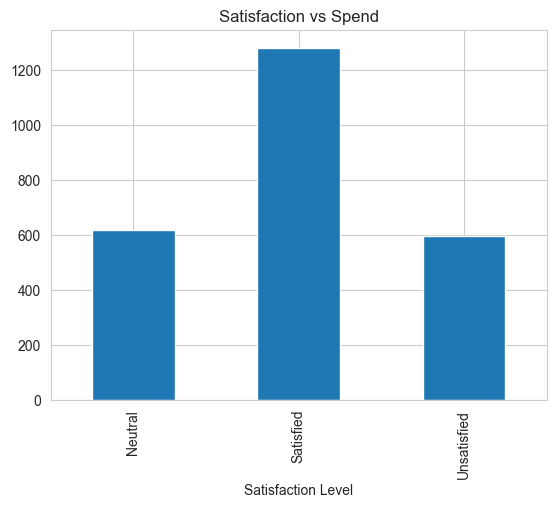

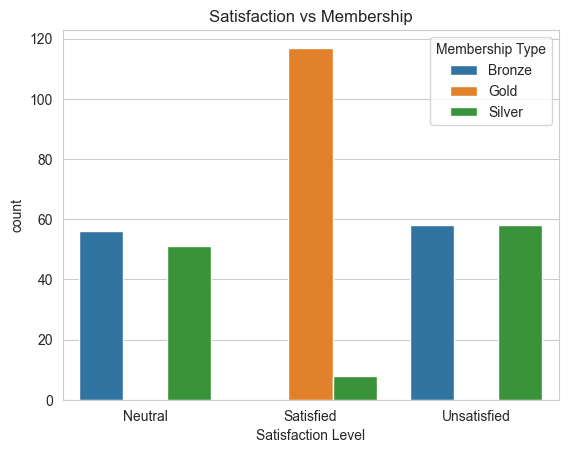

In [10]:
sat = df.groupby(
    "Satisfaction Level"
)["Total Spend"].mean()

print("\nSatisfaction vs Spend")
print(sat)

sat.plot(
    kind="bar",
    title="Satisfaction vs Spend"
)
plt.show()


sns.countplot(
    x="Satisfaction Level",
    hue="Membership Type",
    data=df
)

plt.title("Satisfaction vs Membership")
plt.show()


Churn Count
Churn Risk
Low     307
High     41
Name: count, dtype: int64


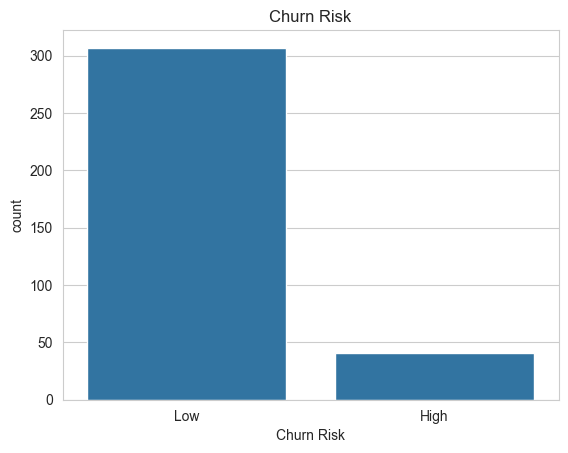


Churn by Membership
Membership Type
Bronze    31.780702
Gold      17.940171
Silver    30.256410
Name: Days Since Last Purchase, dtype: float64


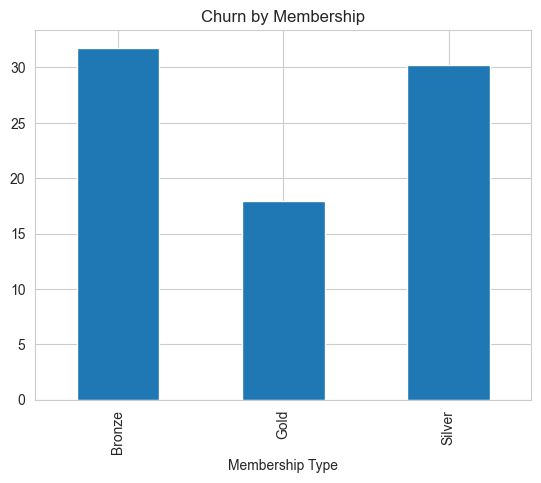


Churn by City
City
Chicago          40.465517
Houston          22.785714
Los Angeles      15.271186
Miami            45.500000
New York         24.593220
San Francisco    11.172414
Name: Days Since Last Purchase, dtype: float64


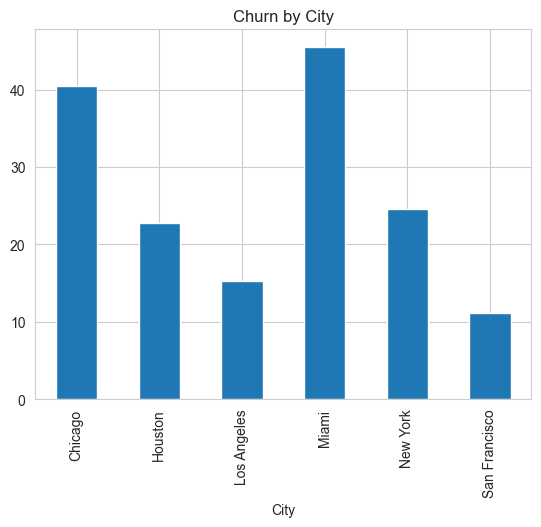

In [11]:
df["Churn Risk"] = df[
    "Days Since Last Purchase"
].apply(
    lambda x: "High" if x > 45 else "Low"
)

print("\nChurn Count")
print(df["Churn Risk"].value_counts())


sns.countplot(
    x="Churn Risk",
    data=df
)

plt.title("Churn Risk")
plt.show()




churn_mem = df.groupby(
    "Membership Type"
)["Days Since Last Purchase"].mean()

print("\nChurn by Membership")
print(churn_mem)

churn_mem.plot(
    kind="bar",
    title="Churn by Membership"
)
plt.show()




churn_city = df.groupby(
    "City"
)["Days Since Last Purchase"].mean()

print("\nChurn by City")
print(churn_city)

churn_city.plot(
    kind="bar",
    title="Churn by City"
)
plt.show()

In [12]:
top = df.sort_values(
    "Total Spend",
    ascending=False
).head(10)

print("\nTop Customers")
print(top)


Top Customers
     Customer ID Gender  Age           City Membership Type  Total Spend  \
9            110   Male   28  San Francisco            Gold       1520.1   
27           128   Male   28  San Francisco            Gold       1500.1   
230          331   Male   28  San Francisco            Gold       1500.1   
117          218   Male   28  San Francisco            Gold       1500.1   
87           188   Male   28  San Francisco            Gold       1500.1   
57           158   Male   28  San Francisco            Gold       1500.1   
159          260   Male   28  San Francisco            Gold       1500.1   
189          290   Male   28  San Francisco            Gold       1500.1   
260          361   Male   28  San Francisco            Gold       1490.1   
284          385   Male   28  San Francisco            Gold       1490.1   

     Items Purchased  Average Rating  Discount Applied  \
9                 21             4.8             False   
27                21            

In [13]:
segment.to_csv("segment.csv")
churn_mem.to_csv("churn_membership.csv")
churn_city.to_csv("churn_city.csv")
spend_membership.to_csv("spend_membership.csv")

print("Saved files")

Saved files
